In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns

In [2]:
client_train = pd.read_csv("data/client_train.csv")
client_test = pd.read_csv("data/client_test.csv")
invoice_train = pd.read_csv("data/invoice_train.csv")
invoice_test = pd.read_csv("data/invoice_test.csv")

C:\Users\blabl\AppData\Local\Temp\ipykernel_26832\3353529087.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  invoice_train = pd.read_csv("data/invoice_train.csv")


In [3]:
invoice_train.query("counter_coefficient == 6")

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
1178200,train_Client_13203,2010-11-19,11,170,769,0,207,6,1,479,0,0,0,717,1196,ELEC
1178205,train_Client_13203,2011-11-21,11,170,769,0,207,6,1,642,0,0,0,2086,2728,ELEC
1178207,train_Client_13203,2011-07-21,11,170,769,0,207,6,1,453,0,0,0,1633,2086,ELEC
1178209,train_Client_13203,2011-03-29,11,170,769,0,207,6,1,437,0,0,0,1196,1633,ELEC
1178211,train_Client_13203,2010-07-19,11,170,769,0,207,6,1,385,0,0,0,332,717,ELEC
1178214,train_Client_13203,2010-03-24,11,170,769,0,207,6,1,332,0,0,0,0,332,ELEC
2556034,train_Client_47780,2017-08-16,11,752,618,0,413,6,1,0,0,0,0,2,2,ELEC
2556037,train_Client_47780,2016-04-18,11,752,618,0,413,6,1,0,0,0,0,2,2,ELEC
2556038,train_Client_47780,2019-04-19,11,752,618,0,413,6,1,0,0,0,0,3,3,ELEC
2556039,train_Client_47780,2016-12-20,11,752,618,0,413,6,1,0,0,0,0,2,2,ELEC


In [4]:
client_train.head()

,disrict,client_id,client_catg,region,creation_date,target
0,60,train_Client_0,11,101,31/12/1994,0.0
1,69,train_Client_1,11,107,29/05/2002,0.0
2,62,train_Client_10,11,301,13/03/1986,0.0
3,69,train_Client_100,11,105,11/07/1996,0.0
4,62,train_Client_1000,11,303,14/10/2014,0.0


In [5]:
client_train.tail()

,disrict,client_id,client_catg,region,creation_date,target
135488,62,train_Client_99995,11,304,26/07/2004,0.0
135489,63,train_Client_99996,11,311,25/10/2012,0.0
135490,63,train_Client_99997,11,311,22/11/2011,0.0
135491,60,train_Client_99998,11,101,22/12/1993,0.0
135492,60,train_Client_99999,11,101,18/02/1986,0.0


In [6]:
client_train.columns

Index(['disrict', 'client_id', 'client_catg', 'region', 'creation_date',
       'target'],
      dtype='object')

In [7]:
client_train.duplicated().sum()

0

In [8]:
client_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   disrict        135493 non-null  int64  
 1   client_id      135493 non-null  object 
 2   client_catg    135493 non-null  int64  
 3   region         135493 non-null  int64  
 4   creation_date  135493 non-null  object 
 5   target         135493 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 6.2+ MB


In [9]:
client_train.describe().T

,count,mean,std,min,25%,50%,75%,max
disrict,135493.0,63.511222,3.354400,60.0,62.0,62.0,69.0,69.0
client_catg,135493.0,11.512506,4.423761,11.0,11.0,11.0,11.0,51.0
region,135493.0,206.159809,104.207044,101.0,103.0,107.0,307.0,399.0
target,135493.0,0.055841,0.229614,0.0,0.0,0.0,0.0,1.0


In [10]:
print(f"Client Train Shape:{client_train.shape}")
print(f"Invoice Train Shape:{invoice_train.shape}")

Client Train Shape:(135493, 6)
Invoice Train Shape:(4476749, 16)


In [11]:
target_1 = client_train.query("target == 1").shape[0]
target_0 = client_train.query("target == 0").shape[0]
percent = (target_1 / (target_1 + target_0)) * 100
percent

5.584052312665599

Text(0.5, 1.0, 'Target Distribution')

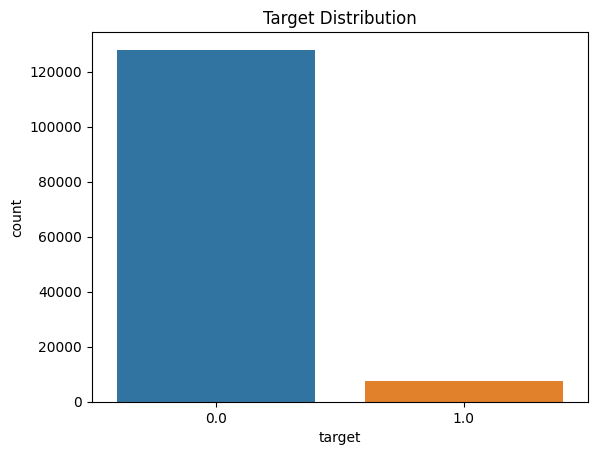

In [12]:
sns.countplot(x="target", data=client_train)
plt.title("Target Distribution")

- client_cat -> mind. 75% = 11
- create_data -> object ? better datetime
- target imbalanced !!!

In [13]:
invoice_train.tail()

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
4476744,train_Client_99998,2005-08-19,10,1253571,0,202,9,1,400,135,0,0,3197,3732,8,ELEC
4476745,train_Client_99998,2005-12-19,10,1253571,0,202,6,1,200,6,0,0,3732,3938,4,ELEC
4476746,train_Client_99999,1996-09-25,11,560948,0,203,6,1,259,0,0,0,13884,14143,4,ELEC
4476747,train_Client_99999,1996-05-28,11,560948,0,203,6,1,603,0,0,0,13281,13884,4,ELEC
4476748,train_Client_99999,1996-01-25,11,560948,0,203,6,1,516,0,0,0,12765,13281,4,ELEC


In [14]:
invoice_train.head()

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,ELEC
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,0,0,14624,14747,4,ELEC
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,0,0,14747,14849,4,ELEC
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,0,0,15066,15638,12,ELEC


In [15]:
invoice_train.columns

Index(['client_id', 'invoice_date', 'tarif_type', 'counter_number',
       'counter_statue', 'counter_code', 'reading_remarque',
       'counter_coefficient', 'consommation_level_1', 'consommation_level_2',
       'consommation_level_3', 'consommation_level_4', 'old_index',
       'new_index', 'months_number', 'counter_type'],
      dtype='object')

In [16]:
invoice_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4476749 entries, 0 to 4476748
Data columns (total 16 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   client_id             object
 1   invoice_date          object
 2   tarif_type            int64 
 3   counter_number        int64 
 4   counter_statue        object
 5   counter_code          int64 
 6   reading_remarque      int64 
 7   counter_coefficient   int64 
 8   consommation_level_1  int64 
 9   consommation_level_2  int64 
 10  consommation_level_3  int64 
 11  consommation_level_4  int64 
 12  old_index             int64 
 13  new_index             int64 
 14  months_number         int64 
 15  counter_type          object
dtypes: int64(12), object(4)
memory usage: 546.5+ MB


In [17]:
invoice_train.describe().T

,count,mean,std,min,25%,50%,75%,max
tarif_type,4476749.0,2.012804e+01,1.347256e+01,8.0,11.0,11.0,40.0,4.500000e+01
counter_number,4476749.0,1.230587e+11,1.657267e+12,0.0,121108.0,494561.0,1115161.0,2.798115e+13
counter_code,4476749.0,1.724884e+02,1.338871e+02,0.0,5.0,203.0,207.0,6.000000e+02
reading_remarque,4476749.0,7.321702e+00,1.571654e+00,5.0,6.0,8.0,9.0,4.130000e+02
counter_coefficient,4476749.0,1.003040e+00,3.083466e-01,0.0,1.0,1.0,1.0,5.000000e+01
consommation_level_1,4476749.0,4.109795e+02,7.573080e+02,0.0,79.0,274.0,600.0,9.999100e+05
consommation_level_2,4476749.0,1.093225e+02,1.220123e+03,0.0,0.0,0.0,0.0,9.990730e+05
consommation_level_3,4476749.0,2.030620e+01,1.574239e+02,0.0,0.0,0.0,0.0,6.449200e+04
consommation_level_4,4476749.0,5.292588e+01,8.754725e+02,0.0,0.0,0.0,0.0,5.479460e+05
old_index,4476749.0,1.776700e+04,4.036693e+04,0.0,1791.0,7690.0,21660.0,2.800280e+06


- objects: invoice_date, counter_statue, counter_type
- classes, but not with type object: tarif_type, counter_code, reading_remarque, counter_coefficient, months_number

- what about hight consumtion-levels => fraud detection, or a companie ( client_train.client_cat/invoice_train.tarif_type )? 
- same with old_index - new_index
- coefficent, old_index, new_index and the consumtion-levels are belonging together
- what about the high numbers of month_numbers -> error? are that days?

- counter_statue: should have 5 classes but there are more ... 5 of them are strings ( '0' '5' '1' '4' 'A' ) the rest are int

- counter_code: < 100 is this a mistake?

- reading_remarque: compare this to target, because if something is wrong the agent gives a bad score -> according to plots below, low numbers might be bad 

- consommation_levels

In [18]:
invoice_train['tarif_type'].value_counts()

tarif_type
11    2679872
40    1379755
10     276210
15      72422
45      17552
13      11656
14      11611
12      11345
29      10090
9        6039
21        104
8          43
30         35
24          9
18          4
42          1
27          1
Name: count, dtype: int64

In [19]:
print('counter_statue', invoice_train['counter_statue'].unique())
print('counter_type', invoice_train['counter_type'].unique())
print('tarif_type', invoice_train['tarif_type'].unique())
print('counter_code', invoice_train['counter_code'].unique())
print('reading_remarque', invoice_train['reading_remarque'].unique())
print('counter_coefficient', invoice_train['counter_coefficient'].unique())
print('months_number', invoice_train['months_number'].unique())

counter_statue [0 1 5 4 3 2 769 '0' '5' '1' '4' 'A' 618 269375 46 420]
counter_type ['ELEC' 'GAZ']
tarif_type [11 40 15 10 12 14 13 45 29  9 30  8 21 42 27 18 24]
counter_code [203 207 413   5 467 202 420 410  10 483  25 433 407 204 214 442 453 506
 450 403 333 201 102 305 210 101 532  40 310 565 600 307 303 222  65   0
 227 325  16 317 367   1]
reading_remarque [  8   6   9   7 207 413 203   5]
counter_coefficient [ 1  3  0 10  4 33 50 20  2  6 40  9 30  5 11  8]
months_number [     4     12      8 ... 367445 459733 463554]


In [20]:
# observations = 4476749
print('counter_statue == "0"', (invoice_train['counter_statue'] == '0').sum())
print('counter_statue == 0', (invoice_train['counter_statue'] == 0).sum())

counter_statue == "0" 32048
counter_statue == 0 4346960


In [21]:
invoice_client_train = invoice_train.merge(client_train, on="client_id", how="left")

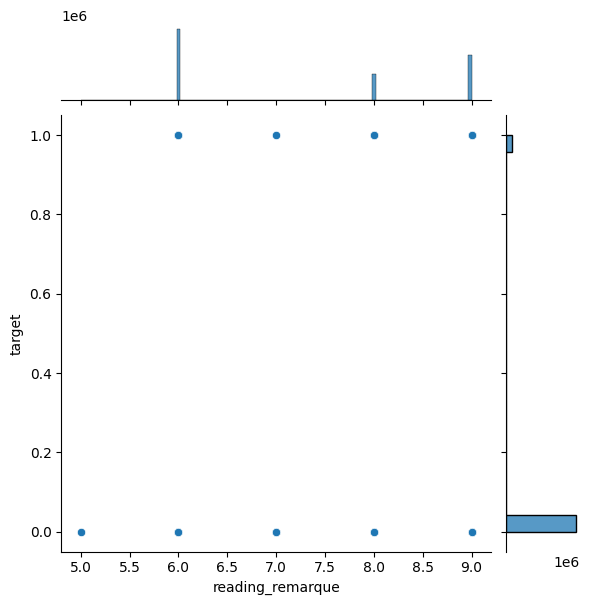

In [22]:
sns.jointplot(x="reading_remarque", y="target", data=invoice_client_train[invoice_client_train['reading_remarque'] <= 20], kind="scatter")

<Axes: xlabel='reading_remarque', ylabel='Count'>

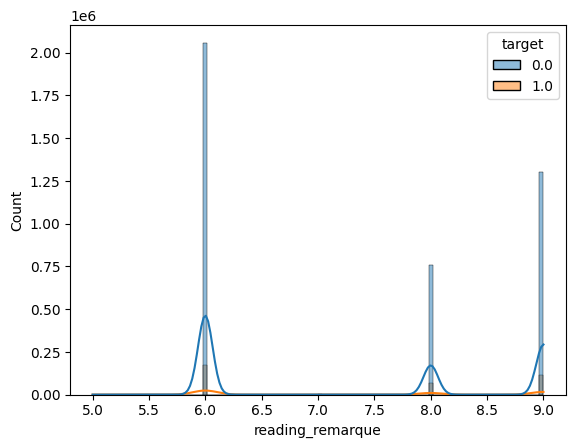

In [23]:
sns.histplot(x="reading_remarque", data=invoice_client_train[invoice_client_train['reading_remarque'] <= 20], hue="target", kde=True)

<Axes: xlabel='reading_remarque', ylabel='Count'>

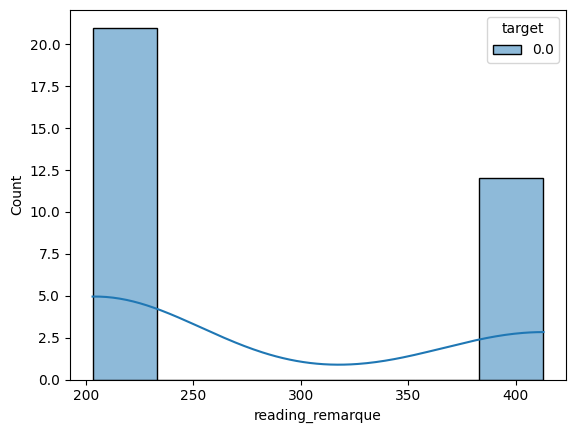

In [24]:
sns.histplot(x="reading_remarque", data=invoice_client_train[invoice_client_train['reading_remarque'] > 20], hue="target", kde=True)

In [25]:
invoice_client_train.query("consommation_level_1 > 0 and consommation_level_2 > 0 and consommation_level_3 > 0 and consommation_level_4 > 0 and counter_coefficient >= 30").sort_values("client_id", ascending=False).head(20)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,consommation_level_4,old_index,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target
2727684,train_Client_52472,2018-03-07,11,840310,0,506,9,30,400,200,...,9560,6817,7169,2,ELEC,60,51,101,31/12/1985,0.0
2727626,train_Client_52472,2014-02-07,11,840310,0,506,9,30,200,100,...,4930,9716,9897,1,ELEC,60,51,101,31/12/1985,0.0
2727622,train_Client_52472,2014-04-11,11,840310,0,506,9,30,200,100,...,4300,416,576,1,ELEC,60,51,101,31/12/1985,0.0
2727607,train_Client_52472,2019-03-09,11,840310,0,506,9,30,400,200,...,14870,9308,9837,2,ELEC,60,51,101,31/12/1985,0.0
2727606,train_Client_52472,2019-04-03,11,840310,0,506,9,30,600,300,...,14070,8205,8724,3,ELEC,60,51,101,31/12/1985,0.0
2727605,train_Client_52472,2018-02-08,11,840310,0,506,9,30,200,100,...,7690,7169,7442,1,ELEC,60,51,101,31/12/1985,0.0
2727604,train_Client_52472,2018-02-03,11,840310,0,506,9,30,400,200,...,8120,6260,6564,2,ELEC,60,51,101,31/12/1985,0.0
2727602,train_Client_52472,2017-05-12,11,840310,0,506,9,30,200,100,...,4930,5958,6139,1,ELEC,60,51,101,31/12/1985,0.0
2727599,train_Client_52472,2016-02-09,11,840310,0,506,9,30,400,200,...,10820,3397,3791,2,ELEC,60,51,101,31/12/1985,0.0
2727598,train_Client_52472,2018-03-05,11,840310,0,506,9,30,400,200,...,6590,6564,6817,2,ELEC,60,51,101,31/12/1985,0.0


In [26]:
invoice_train.query("consommation_level_1 > 0 and consommation_level_2 > 0 and consommation_level_3 > 0 and consommation_level_4 > 0").sort_values("client_id", ascending=False).groupby("counter_coefficient").size()

counter_coefficient
1     92544
2       215
3        73
30       47
40       79
dtype: int64

In [27]:
invoice_client_train.query("consommation_level_1 > 0 and consommation_level_2 > 0 and consommation_level_3 > 0 and consommation_level_4 > 0 and target == 1.0").sort_values("client_id", ascending=False)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,consommation_level_4,old_index,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target
4473671,train_Client_99917,2017-01-03,11,6736,0,413,8,1,1200,600,...,494,152847,156341,6,ELEC,69,51,103,11/04/2011,1.0
4473649,train_Client_99917,2019-03-01,11,2178700007973,0,420,9,1,200,100,...,1014,19910,21424,1,ELEC,69,51,103,11/04/2011,1.0
4473632,train_Client_99917,2019-03-09,11,2178700007973,0,420,9,1,200,100,...,1764,31281,33545,1,ELEC,69,51,103,11/04/2011,1.0
4473634,train_Client_99917,2019-02-08,11,2178700007973,0,420,9,1,200,100,...,1326,29455,31281,1,ELEC,69,51,103,11/04/2011,1.0
4473636,train_Client_99917,2019-02-07,11,2178700007973,0,420,9,1,400,200,...,1613,26842,29455,2,ELEC,69,51,103,11/04/2011,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8256,train_Client_100236,2019-02-07,11,586403,0,420,9,1,200,100,...,126,41825,42451,1,ELEC,62,51,301,28/03/2012,1.0
8258,train_Client_100236,2016-10-13,11,586403,0,420,9,1,800,400,...,32,12891,14923,4,ELEC,62,51,301,28/03/2012,1.0
8259,train_Client_100236,2016-07-06,11,586403,0,420,9,1,800,400,...,1007,9884,12891,4,ELEC,62,51,301,28/03/2012,1.0
8260,train_Client_100236,2016-02-15,11,586403,0,420,9,1,800,400,...,1539,6345,9884,4,ELEC,62,51,301,28/03/2012,1.0


In [28]:
invoice_client_train.shape

(4476749, 21)

In [29]:
invoice_client_train.query("consommation_level_1 > 0 and consommation_level_2 > 0 and consommation_level_3 > 0 and consommation_level_4 > 0 and target == 1.0").groupby("client_id").size().shape

(2303,)

In [30]:
invoice_client_train.query("consommation_level_1 > 0 and consommation_level_2 > 0 and consommation_level_3 > 0 and consommation_level_4 > 0 and target == 1.0 and reading_remarque > 10").sort_values("client_id", ascending=False)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,consommation_level_4,old_index,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target


In [31]:
invoice_client_train['new-old_index'] = (invoice_client_train['new_index'] - invoice_client_train['old_index'])*invoice_client_train['counter_coefficient']
invoice_client_train['new-old_index']
invoice_client_train['add_consommation_levels'] = invoice_client_train['consommation_level_1'] + invoice_client_train['consommation_level_2'] + invoice_client_train['consommation_level_3'] + invoice_client_train['consommation_level_4']

In [32]:
invoice_client_train[['add_consommation_levels', 'new-old_index']]

,add_consommation_levels,new-old_index
0,82,82
1,1384,1384
2,123,123
3,102,102
4,572,572
...,...,...
4476744,535,535
4476745,206,206
4476746,259,259
4476747,603,603


In [33]:
invoice_client_train.query('add_consommation_levels != `new-old_index`').sort_values('client_id', ascending=False)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
4476647,train_Client_99995,2008-02-26,40,156063,0,5,6,1,139,0,...,0,4,GAZ,62,11,304,26/07/2004,0.0,0,139
4476420,train_Client_99988,2012-05-01,40,70623,0,5,6,1,61,0,...,1550,4,GAZ,63,11,101,10/12/2002,0.0,0,61
4476318,train_Client_99985,2006-10-18,11,974695,0,532,6,3,1200,48618,...,16514,4,ELEC,60,51,101,31/12/1994,0.0,-250182,49818
4475991,train_Client_99978,2011-08-12,40,7006449,0,5,6,1,395,0,...,2481,6,GAZ,69,11,104,30/10/1995,0.0,0,395
4475524,train_Client_99964,2010-08-11,15,403585,0,202,9,1,215,0,...,4335,2,ELEC,60,11,101,04/10/1978,0.0,0,215
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,train_Client_10008,2015-05-01,11,842528,0,413,9,1,800,400,...,1849,4,ELEC,63,11,101,14/09/1987,0.0,-97637,2363
2632,train_Client_100075,2008-11-27,11,502690,0,410,6,1,116,0,...,0,14,ELEC,60,11,101,13/09/2007,0.0,0,116
1865,train_Client_100050,2012-01-25,11,112753,0,413,9,1,2400,543,...,7709,8,ELEC,63,11,311,31/12/1994,0.0,0,2943
1215,train_Client_100025,2012-02-17,11,1028965,0,203,6,1,372,0,...,7300,4,ELEC,63,11,311,15/12/2005,0.0,348,372


In [34]:
invoice_client_train.query('add_consommation_levels != `new-old_index` and reading_remarque > 10').sort_values('client_id', ascending=False)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
3677153,train_Client_78338,2008-02-20,11,992,46,0,203,6,1,819,...,49086,49905,ELEC,62,11,304,13/10/1980,0.0,294516,820
3677152,train_Client_78338,2007-10-18,11,992,46,0,203,6,1,1817,...,47269,49086,ELEC,62,11,304,13/10/1980,0.0,283614,1818
3677149,train_Client_78338,2006-06-21,11,992,46,0,203,6,1,2240,...,42833,45073,ELEC,62,11,304,13/10/1980,0.0,256998,2241
3677146,train_Client_78338,2010-10-14,11,992,46,0,203,6,1,930,...,55937,56867,ELEC,62,11,304,13/10/1980,0.0,335622,931
3677144,train_Client_78338,2006-10-16,11,992,46,0,203,6,1,1152,...,45073,46225,ELEC,62,11,304,13/10/1980,0.0,270438,1153
3677142,train_Client_78338,2007-02-19,11,992,46,0,203,6,1,1044,...,46225,47269,ELEC,62,11,304,13/10/1980,0.0,277350,1045
3677131,train_Client_78338,2011-10-14,11,992,46,0,203,9,1,1620,...,57773,59393,ELEC,62,11,304,13/10/1980,0.0,519957,1621
3677125,train_Client_78338,2005-03-10,11,992,46,0,203,6,1,980,...,41853,42833,ELEC,62,11,304,13/10/1980,0.0,251118,981
3677121,train_Client_78338,2009-10-16,11,992,46,0,203,6,1,1040,...,53257,53257,ELEC,62,11,304,13/10/1980,0.0,319542,1041
3677119,train_Client_78338,2010-06-16,11,992,46,0,203,8,1,755,...,55182,55937,ELEC,62,11,304,13/10/1980,0.0,441456,756


In [35]:
invoice_client_train.query('add_consommation_levels != `new-old_index` and target == 1.0').sort_values('counter_coefficient', ascending=False)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
700544,train_Client_118876,2006-10-25,11,160600,1,410,6,10,600,580,...,0,2,ELEC,62,11,304,27/09/1977,1.0,0,1180
3004,train_Client_100083,2012-02-16,40,6788434,0,5,8,1,204,0,...,1469,12,GAZ,69,11,107,26/10/1982,1.0,0,204
2721620,train_Client_52310,2012-01-25,11,98239,0,413,8,1,770,0,...,20556,4,ELEC,69,11,107,16/09/2003,1.0,0,770
2716625,train_Client_52162,2019-08-14,11,2178700029416,0,413,9,1,44,0,...,8832,2,ELEC,69,11,104,16/03/2017,1.0,306,44
2716623,train_Client_52162,2019-10-04,11,2178700029416,0,413,9,1,352,0,...,7378,2,ELEC,69,11,104,16/03/2017,1.0,484,352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1352846,train_Client_14780,2005-12-23,11,922455,0,506,6,1,5,1200,...,87212,90468,ELEC,63,51,312,30/04/2003,1.0,87212,4889
1352845,train_Client_14780,2017-03-05,11,922455,0,506,9,1,5,200,...,27008,29728,ELEC,63,51,312,30/04/2003,1.0,23428,505
1352844,train_Client_14780,2015-05-05,11,922455,0,506,9,1,5,200,...,65350,66741,ELEC,63,51,312,30/04/2003,1.0,63764,505
1352843,train_Client_14780,2014-04-11,11,922455,0,506,9,1,5,200,...,56051,57964,ELEC,63,51,312,30/04/2003,1.0,53682,505


In [36]:
invoice_client_train.query('add_consommation_levels == `new-old_index` and target == 1.0')

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
1384,train_Client_100032,2017-02-24,11,393848,0,203,9,1,781,0,...,4625,8,ELEC,63,11,308,07/11/2012,1.0,781,781
1385,train_Client_100032,2016-06-21,11,393848,0,203,9,1,382,0,...,3844,4,ELEC,63,11,308,07/11/2012,1.0,382,382
1386,train_Client_100032,2018-10-26,11,393848,0,203,9,1,373,0,...,6405,4,ELEC,63,11,308,07/11/2012,1.0,373,373
1387,train_Client_100032,2018-06-21,11,393848,0,203,9,1,328,0,...,6032,4,ELEC,63,11,308,07/11/2012,1.0,328,328
1388,train_Client_100032,2018-02-23,11,393848,0,203,9,1,703,0,...,5704,4,ELEC,63,11,308,07/11/2012,1.0,703,703
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4476230,train_Client_99982,2010-11-22,10,1379797,0,202,8,1,200,192,...,17951,4,ELEC,63,11,379,21/11/1995,1.0,392,392
4476231,train_Client_99982,2011-07-19,10,1379797,0,202,6,1,200,98,...,18569,4,ELEC,63,11,379,21/11/1995,1.0,298,298
4476232,train_Client_99982,2012-03-19,10,1379797,0,202,8,1,187,0,...,19120,4,ELEC,63,11,379,21/11/1995,1.0,187,187
4476233,train_Client_99982,2013-03-21,10,1379797,0,202,8,1,95,0,...,19677,4,ELEC,63,11,379,21/11/1995,1.0,95,95


In [37]:
df_ungleich = invoice_client_train.query('add_consommation_levels != `new-old_index` and target == 1.0').sort_values('client_id', ascending=False)
df_gleich = invoice_client_train.query('add_consommation_levels == `new-old_index` and target == 1.0').sort_values('client_id', ascending=False)

<Axes: xlabel='add_consommation_levels', ylabel='new-old_index'>

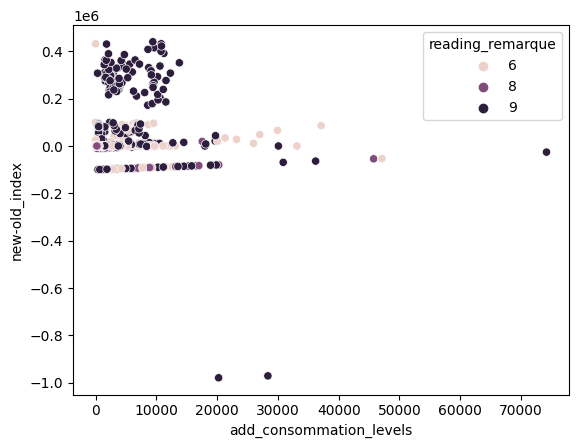

In [38]:
sns.scatterplot(data=df_ungleich, x='add_consommation_levels', y='new-old_index', hue='reading_remarque')

<Axes: xlabel='add_consommation_levels', ylabel='new-old_index'>

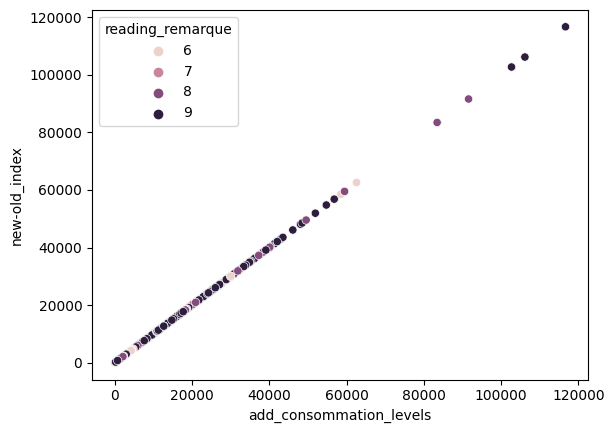

In [39]:
sns.scatterplot(data=df_gleich, x='add_consommation_levels', y='new-old_index', hue='reading_remarque')

are reading_remarque and counter_statue releated

<Axes: xlabel='reading_remarque', ylabel='count'>

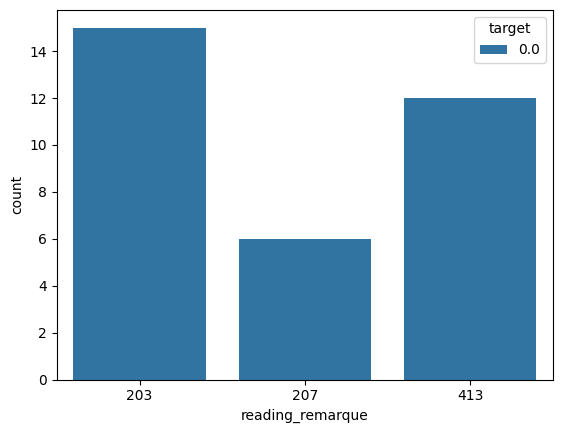

In [40]:
sns.countplot(x="reading_remarque", data=invoice_client_train[invoice_client_train['reading_remarque'] > 20], hue="target")

<Axes: xlabel='reading_remarque', ylabel='count'>

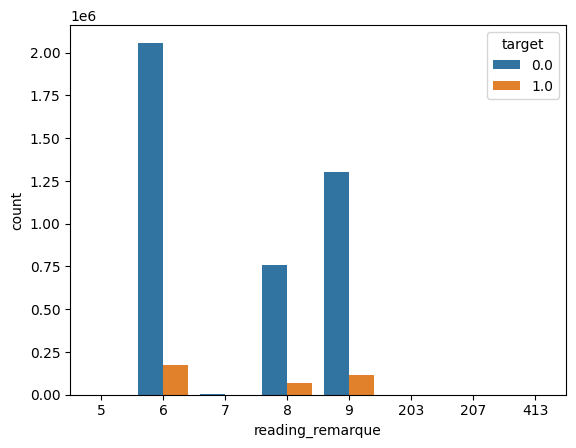

In [41]:
sns.countplot(x="reading_remarque", data=invoice_client_train, hue="target")

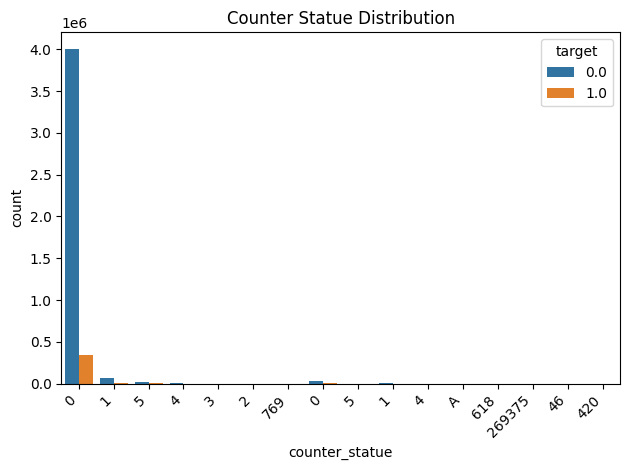

In [42]:
sns.countplot(x="counter_statue", data=invoice_client_train, hue="target")
plt.title("Counter Statue Distribution")
plt.xticks(rotation=45, ha='right')  # ha='right' sorgt dafür, dass die Texte rechtsbündig an den Tick-Markern ausgerichtet sind (sieht meist besser aus)

plt.tight_layout()  # Verhindert, dass abgeschnittene Texte am Rand stehen
plt.show()

In [43]:
invoice_client_train['counter_number'].sort_values(ascending=True).value_counts()

counter_number
0                 43161
2786                251
630317              230
162709              226
963                 220
                  ...  
185305                1
185332                1
2175800004468         1
185392                1
27981145458733        1
Name: count, Length: 201893, dtype: int64

In [44]:
invoice_client_train['counter_code'].sort_values(ascending=True).value_counts()


counter_code
203    1516836
5      1352035
207     555628
413     378917
202     343251
420      98273
410      69080
433      34447
10       27744
442      17050
25       14934
407      13768
204      12427
453       8290
201       7672
467       7302
506       3389
483       2830
214       2643
40        2482
532       1982
565       1082
403       1070
450       1059
600        807
210        789
102        313
227        178
101         74
65          74
16          73
310         51
307         50
305         44
222         42
0           33
317         16
303          5
333          4
367          3
325          1
1            1
Name: count, dtype: int64

In [45]:
invoice_client_train['tarif_type'].value_counts()

tarif_type
11    2679872
40    1379755
10     276210
15      72422
45      17552
13      11656
14      11611
12      11345
29      10090
9        6039
21        104
8          43
30         35
24          9
18          4
42          1
27          1
Name: count, dtype: int64

In [46]:
invoice_client_train['counter_coefficient'].value_counts()

counter_coefficient
1     4475102
2         886
3         321
40        197
30        137
0          46
6          30
4          12
10          6
20          3
9           3
50          2
33          1
5           1
11          1
8           1
Name: count, dtype: int64

In [47]:
invoice_client_train['counter_statue'].value_counts()

counter_statue
0         4346960
1           73496
0           32048
5           20495
4            2706
1             540
3             258
5             144
2              32
4              23
46             14
A              13
618            12
769             6
269375          1
420             1
Name: count, dtype: int64

In [48]:
invoice_client_train['reading_remarque'].value_counts()

reading_remarque
6      2230939
9      1416992
8       828123
7          661
203         15
413         12
207          6
5            1
Name: count, dtype: int64

In [49]:
# counter_coefficient == 6
invoice_client_train.query("counter_coefficient == 6").sort_values("invoice_date", ascending=False)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
2556042,train_Client_47780,2019-08-23,11,752,618,0,413,6,1,0,...,3,3,ELEC,63,11,306,08/05/2015,0.0,18,1
2556038,train_Client_47780,2019-04-19,11,752,618,0,413,6,1,0,...,3,3,ELEC,63,11,306,08/05/2015,0.0,18,1
2556043,train_Client_47780,2018-12-21,11,752,618,0,413,6,1,0,...,3,3,ELEC,63,11,306,08/05/2015,0.0,18,1
2556044,train_Client_47780,2018-08-14,11,752,618,0,413,6,1,0,...,3,3,ELEC,63,11,306,08/05/2015,0.0,18,1
2556040,train_Client_47780,2018-04-17,11,752,618,0,413,6,1,0,...,3,3,ELEC,63,11,306,08/05/2015,0.0,18,1
2556034,train_Client_47780,2017-08-16,11,752,618,0,413,6,1,0,...,2,2,ELEC,63,11,306,08/05/2015,0.0,12,1
2556041,train_Client_47780,2017-04-17,11,752,618,0,413,6,1,0,...,2,2,ELEC,63,11,306,08/05/2015,0.0,12,1
2556039,train_Client_47780,2016-12-20,11,752,618,0,413,6,1,0,...,2,2,ELEC,63,11,306,08/05/2015,0.0,12,1
2556045,train_Client_47780,2016-08-18,11,752,618,0,413,6,1,0,...,2,2,ELEC,63,11,306,08/05/2015,0.0,12,1
2556037,train_Client_47780,2016-04-18,11,752,618,0,413,6,1,0,...,2,2,ELEC,63,11,306,08/05/2015,0.0,12,1


In [50]:
invoice_client_train.query("client_id == 'train_Client_47780'").sort_values("invoice_date", ascending=False)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
2556042,train_Client_47780,2019-08-23,11,752,618,0,413,6,1,0,...,3,3,ELEC,63,11,306,08/05/2015,0.0,18,1
2556038,train_Client_47780,2019-04-19,11,752,618,0,413,6,1,0,...,3,3,ELEC,63,11,306,08/05/2015,0.0,18,1
2556043,train_Client_47780,2018-12-21,11,752,618,0,413,6,1,0,...,3,3,ELEC,63,11,306,08/05/2015,0.0,18,1
2556044,train_Client_47780,2018-08-14,11,752,618,0,413,6,1,0,...,3,3,ELEC,63,11,306,08/05/2015,0.0,18,1
2556040,train_Client_47780,2018-04-17,11,752,618,0,413,6,1,0,...,3,3,ELEC,63,11,306,08/05/2015,0.0,18,1
2556035,train_Client_47780,2017-12-19,11,752,618,0,413,9,1,1,...,2,3,ELEC,63,11,306,08/05/2015,0.0,18,2
2556034,train_Client_47780,2017-08-16,11,752,618,0,413,6,1,0,...,2,2,ELEC,63,11,306,08/05/2015,0.0,12,1
2556041,train_Client_47780,2017-04-17,11,752,618,0,413,6,1,0,...,2,2,ELEC,63,11,306,08/05/2015,0.0,12,1
2556039,train_Client_47780,2016-12-20,11,752,618,0,413,6,1,0,...,2,2,ELEC,63,11,306,08/05/2015,0.0,12,1
2556045,train_Client_47780,2016-08-18,11,752,618,0,413,6,1,0,...,2,2,ELEC,63,11,306,08/05/2015,0.0,12,1


In [51]:
# counter_statue == 269375
invoice_client_train.query("client_id == 'train_Client_53725'").sort_values("invoice_date", ascending=False)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
2773073,train_Client_53725,1996-02-04,11,7,269375,0,203,6,1,0,...,796,796,ELEC,60,11,101,15/11/1982,0.0,4776,1


In [52]:
# counter_statue == 420 and reading_remarque == 5 and counter_code == 1 -> they are just one time in the same observation, so we can drop them as well
invoice_client_train.query("client_id == 'train_Client_79075'").sort_values("invoice_date", ascending=False)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
3704441,train_Client_79075,2017-12-01,11,553299,0,410,9,1,800,400,...,57447,4,ELEC,69,11,107,28/11/2011,0.0,6205,6205
3704427,train_Client_79075,2017-08-05,11,553299,0,410,9,1,800,400,...,60530,4,ELEC,69,11,107,28/11/2011,0.0,3083,3083
3704428,train_Client_79075,2017-07-09,11,553299,0,410,9,1,800,400,...,62291,4,ELEC,69,11,107,28/11/2011,0.0,1761,1761
3704433,train_Client_79075,2016-07-09,11,553299,0,410,9,1,800,400,...,51242,4,ELEC,69,11,107,28/11/2011,0.0,5306,5306
3704444,train_Client_79075,2016-06-05,11,553299,0,410,9,1,800,400,...,45936,4,ELEC,69,11,107,28/11/2011,0.0,2716,2716
3704442,train_Client_79075,2016-01-15,11,553299,0,410,9,1,800,400,...,43220,4,ELEC,69,11,107,28/11/2011,0.0,5166,5166
3704431,train_Client_79075,2015-11-05,11,553299,0,410,8,1,800,400,...,30744,4,ELEC,69,11,107,28/11/2011,0.0,3572,3572
3704440,train_Client_79075,2015-04-09,11,553299,0,410,8,1,800,400,...,38054,4,ELEC,69,11,107,28/11/2011,0.0,7310,7310
3704443,train_Client_79075,2015-01-16,11,553299,0,410,9,1,800,400,...,27172,4,ELEC,69,11,107,28/11/2011,0.0,6137,6137
3704429,train_Client_79075,2014-12-05,11,553299,0,410,9,1,800,400,...,12884,4,ELEC,69,11,107,28/11/2011,0.0,2471,2471


In [53]:
invoice_client_train.query("counter_code == 1")

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
3704439,train_Client_79075,2012-01-16,40,412,420,1,5,6,1,0,...,0,0,GAZ,69,11,107,28/11/2011,0.0,0,1


In [54]:
invoice_client_train.query("counter_number == 412")

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
2969845,train_Client_5903,2019-06-13,11,412,0,207,9,1,490,0,...,9095,4,ELEC,62,11,303,31/10/2016,0.0,490,490
2969846,train_Client_5903,2017-05-06,11,412,0,207,9,1,404,0,...,5901,4,ELEC,62,11,303,31/10/2016,0.0,404,404
2969848,train_Client_5903,2017-08-02,11,412,0,207,9,1,405,0,...,5497,3,ELEC,62,11,303,31/10/2016,0.0,405,405
2969850,train_Client_5903,2019-11-02,11,412,0,207,9,1,1102,0,...,8605,8,ELEC,62,11,303,31/10/2016,0.0,1102,1102
2969851,train_Client_5903,2018-01-06,11,412,0,207,9,1,405,0,...,7503,4,ELEC,62,11,303,31/10/2016,0.0,405,405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4342249,train_Client_96354,2016-10-14,40,412,0,5,6,1,105,0,...,7392,4,GAZ,62,11,304,20/11/1997,0.0,105,105
4342250,train_Client_96354,2008-06-16,40,412,0,5,6,1,140,0,...,4373,4,GAZ,62,11,304,20/11/1997,0.0,140,140
4342252,train_Client_96354,2008-10-14,40,412,0,5,6,1,81,0,...,4454,4,GAZ,62,11,304,20/11/1997,0.0,81,81
4342254,train_Client_96354,2005-09-28,40,412,0,5,8,1,16,0,...,3039,4,GAZ,62,11,304,20/11/1997,0.0,16,16


In [55]:
# counter_statue == 769 and reading_remarque == 207 ???
df = invoice_client_train.query("counter_statue == 769").sort_values("invoice_date", ascending=False)
df.drop(columns=["client_id", "invoice_date", "target"], inplace=True)
df

,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,new-old_index,add_consommation_levels
1178205,11,170,769,0,207,6,1,642,0,0,0,2086,2728,ELEC,62,11,301,04/01/2010,12516,643
1178207,11,170,769,0,207,6,1,453,0,0,0,1633,2086,ELEC,62,11,301,04/01/2010,9798,454
1178209,11,170,769,0,207,6,1,437,0,0,0,1196,1633,ELEC,62,11,301,04/01/2010,7176,438
1178200,11,170,769,0,207,6,1,479,0,0,0,717,1196,ELEC,62,11,301,04/01/2010,4302,480
1178211,11,170,769,0,207,6,1,385,0,0,0,332,717,ELEC,62,11,301,04/01/2010,1992,386
1178214,11,170,769,0,207,6,1,332,0,0,0,0,332,ELEC,62,11,301,04/01/2010,0,333


In [56]:
invoice_client_train.query("client_id == 'train_Client_13203'").sort_values(["tarif_type", "invoice_date"], ascending=False)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
1178215,train_Client_13203,2014-07-16,40,3005224,0,5,6,1,84,0,...,1350,4,GAZ,62,11,301,04/01/2010,0.0,84,84
1178217,train_Client_13203,2014-03-19,40,3005224,0,5,6,1,110,0,...,1266,4,GAZ,62,11,301,04/01/2010,0.0,110,110
1178201,train_Client_13203,2013-11-27,40,3005224,0,5,6,1,89,0,...,1156,4,GAZ,62,11,301,04/01/2010,0.0,89,89
1178206,train_Client_13203,2013-07-18,40,3005224,0,5,6,1,29,0,...,1061,2,GAZ,62,11,301,04/01/2010,0.0,29,29
1178198,train_Client_13203,2013-03-27,40,3005224,0,5,6,1,76,0,...,988,2,GAZ,62,11,301,04/01/2010,0.0,76,76
1178202,train_Client_13203,2012-11-27,40,3005224,0,5,6,1,106,0,...,818,4,GAZ,62,11,301,04/01/2010,0.0,106,106
1178203,train_Client_13203,2012-07-19,40,3005224,0,5,6,1,101,0,...,712,4,GAZ,62,11,301,04/01/2010,0.0,101,101
1178204,train_Client_13203,2012-03-23,40,3005224,0,5,6,1,163,0,...,611,4,GAZ,62,11,301,04/01/2010,0.0,163,163
1178197,train_Client_13203,2011-11-21,40,3005224,0,5,6,1,54,0,...,448,4,GAZ,62,11,301,04/01/2010,0.0,54,54
1178216,train_Client_13203,2011-07-21,40,3005224,0,5,8,1,59,0,...,394,4,GAZ,62,11,301,04/01/2010,0.0,59,59


In [57]:
invoice_client_train.query("counter_number == 170 and client_id != 'train_Client_13203'").sort_values("months_number", ascending=False)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
2565516,train_Client_48051,2019-03-27,11,170,0,203,8,1,2205,0,...,11993,12,ELEC,69,11,104,28/09/2000,0.0,2205,2205
113779,train_Client_10308,2017-09-26,11,170,0,413,8,1,0,0,...,25195,12,ELEC,63,11,311,18/12/2014,0.0,11475,0
4166920,train_Client_91567,2014-04-28,11,170,0,420,8,1,11,0,...,8445,8,ELEC,63,12,312,26/06/2009,0.0,11,11
4166918,train_Client_91567,2012-04-26,11,170,0,420,9,1,1800,1238,...,6335,6,ELEC,63,12,312,26/06/2009,0.0,3038,3038
4166926,train_Client_91567,2018-04-23,11,170,0,420,6,1,0,0,...,8692,4,ELEC,63,12,312,26/06/2009,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2565544,train_Client_48051,2015-11-24,11,170,0,203,8,1,50,0,...,4690,2,ELEC,69,11,104,28/09/2000,0.0,50,50
2565510,train_Client_48051,2015-03-27,11,170,0,203,8,1,23,0,...,4406,2,ELEC,69,11,104,28/09/2000,0.0,23,23
2565513,train_Client_48051,2016-11-24,11,170,0,203,9,1,400,200,...,8661,2,ELEC,69,11,104,28/09/2000,0.0,2305,2305
2565537,train_Client_48051,2014-11-21,11,170,0,203,8,1,12,0,...,4383,2,ELEC,69,11,104,28/09/2000,0.0,12,12


In [58]:
# counter_statue == 618 and reading_remarque == 413 ???
df = invoice_client_train.query("counter_statue == 618").sort_values("invoice_date", ascending=False)
df

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
2556042,train_Client_47780,2019-08-23,11,752,618,0,413,6,1,0,...,3,3,ELEC,63,11,306,08/05/2015,0.0,18,1
2556038,train_Client_47780,2019-04-19,11,752,618,0,413,6,1,0,...,3,3,ELEC,63,11,306,08/05/2015,0.0,18,1
2556043,train_Client_47780,2018-12-21,11,752,618,0,413,6,1,0,...,3,3,ELEC,63,11,306,08/05/2015,0.0,18,1
2556044,train_Client_47780,2018-08-14,11,752,618,0,413,6,1,0,...,3,3,ELEC,63,11,306,08/05/2015,0.0,18,1
2556040,train_Client_47780,2018-04-17,11,752,618,0,413,6,1,0,...,3,3,ELEC,63,11,306,08/05/2015,0.0,18,1
2556035,train_Client_47780,2017-12-19,11,752,618,0,413,9,1,1,...,2,3,ELEC,63,11,306,08/05/2015,0.0,18,2
2556034,train_Client_47780,2017-08-16,11,752,618,0,413,6,1,0,...,2,2,ELEC,63,11,306,08/05/2015,0.0,12,1
2556041,train_Client_47780,2017-04-17,11,752,618,0,413,6,1,0,...,2,2,ELEC,63,11,306,08/05/2015,0.0,12,1
2556039,train_Client_47780,2016-12-20,11,752,618,0,413,6,1,0,...,2,2,ELEC,63,11,306,08/05/2015,0.0,12,1
2556045,train_Client_47780,2016-08-18,11,752,618,0,413,6,1,0,...,2,2,ELEC,63,11,306,08/05/2015,0.0,12,1


In [59]:
# counter_statue == 46 and reading_remarque == 203 ???
df = invoice_client_train.query("counter_statue == 46").sort_values("invoice_date", ascending=False)
df

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
3677131,train_Client_78338,2011-10-14,11,992,46,0,203,9,1,1620,...,57773,59393,ELEC,62,11,304,13/10/1980,0.0,519957,1621
3677146,train_Client_78338,2010-10-14,11,992,46,0,203,6,1,930,...,55937,56867,ELEC,62,11,304,13/10/1980,0.0,335622,931
3677119,train_Client_78338,2010-06-16,11,992,46,0,203,8,1,755,...,55182,55937,ELEC,62,11,304,13/10/1980,0.0,441456,756
3677114,train_Client_78338,2010-02-18,11,992,46,0,203,6,1,1925,...,53257,55182,ELEC,62,11,304,13/10/1980,0.0,319542,1926
3677121,train_Client_78338,2009-10-16,11,992,46,0,203,6,1,1040,...,53257,53257,ELEC,62,11,304,13/10/1980,0.0,319542,1041
3677115,train_Client_78338,2009-06-18,11,992,46,0,203,6,1,717,...,52540,53257,ELEC,62,11,304,13/10/1980,0.0,315240,718
3677111,train_Client_78338,2009-02-17,11,992,46,0,203,6,1,870,...,51670,52540,ELEC,62,11,304,13/10/1980,0.0,310020,871
3677108,train_Client_78338,2008-10-17,11,992,46,0,203,6,1,1765,...,49905,51670,ELEC,62,11,304,13/10/1980,0.0,299430,1766
3677153,train_Client_78338,2008-02-20,11,992,46,0,203,6,1,819,...,49086,49905,ELEC,62,11,304,13/10/1980,0.0,294516,820
3677152,train_Client_78338,2007-10-18,11,992,46,0,203,6,1,1817,...,47269,49086,ELEC,62,11,304,13/10/1980,0.0,283614,1818


In [60]:

# counter_statue == 4 and reading_remarque == 6,9
df = invoice_client_train.query("counter_statue == '4'").sort_values("invoice_date", ascending=False)
df

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
1933062,train_Client_30751,2007-07-13,11,3578,4,407,6,1,1200,663,...,64000,4,ELEC,60,11,101,28/03/1986,0.0,1863,1863
1907501,train_Client_30035,2007-05-28,11,61578,4,420,6,1,1200,2270,...,77803,4,ELEC,69,11,104,03/05/1994,0.0,3470,3470
1917157,train_Client_30295,2007-05-18,11,526911,4,203,9,1,421,0,...,16171,4,ELEC,69,11,104,13/12/1985,1.0,421,421
1933057,train_Client_30751,2007-03-14,11,3578,4,407,6,1,1200,197,...,62137,4,ELEC,60,11,101,28/03/1986,0.0,1397,1397
1902143,train_Client_29893,2007-02-22,11,211813,4,203,6,1,422,0,...,22975,4,ELEC,69,11,104,31/12/1981,0.0,422,422
1907522,train_Client_30035,2007-01-25,11,61578,4,420,6,1,1200,2090,...,74333,4,ELEC,69,11,104,03/05/1994,0.0,3290,3290
1917174,train_Client_30295,2007-01-16,11,526911,4,203,6,1,277,0,...,15750,4,ELEC,69,11,104,13/12/1985,1.0,277,277
1933054,train_Client_30751,2006-11-07,11,3578,4,407,6,1,1200,1227,...,58808,4,ELEC,60,11,101,28/03/1986,0.0,2427,2427
1902142,train_Client_29893,2006-10-20,11,211813,4,203,6,1,254,0,...,22553,4,ELEC,69,11,104,31/12/1981,0.0,254,254
1907524,train_Client_30035,2006-09-22,11,61578,4,420,6,1,1200,1186,...,71043,4,ELEC,69,11,104,03/05/1994,0.0,2386,2386


In [61]:
# counter_statue == '5' and reading_remarque == 6
df = invoice_client_train.query("counter_statue == '5' and months_number > 12").sort_values("invoice_date", ascending=False)
df

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
1929468,train_Client_30655,2006-06-04,11,1331322,5,203,6,1,62,0,...,2098,30,ELEC,60,11,101,16/12/1994,0.0,62,62


In [62]:
# Zähler getauscht?
df = invoice_client_train.query("client_id == 'train_Client_30655'").sort_values("invoice_date", ascending=False)
df

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
1929467,train_Client_30655,2019-06-18,11,67200,0,203,8,1,37,0,...,6122,4,ELEC,60,11,101,16/12/1994,0.0,37,37
1929469,train_Client_30655,2019-02-14,11,67200,0,203,9,1,151,0,...,6085,4,ELEC,60,11,101,16/12/1994,0.0,151,151
1929479,train_Client_30655,2016-08-06,11,67200,0,203,8,1,611,0,...,5585,16,ELEC,60,11,101,16/12/1994,0.0,611,611
1929481,train_Client_30655,2015-02-17,11,67200,0,203,8,1,285,0,...,4974,8,ELEC,60,11,101,16/12/1994,0.0,285,285
1929478,train_Client_30655,2014-06-16,11,67200,0,203,8,1,43,0,...,4689,2,ELEC,60,11,101,16/12/1994,0.0,43,43
1929477,train_Client_30655,2013-06-13,11,67200,0,203,8,1,65,0,...,4293,4,ELEC,60,11,101,16/12/1994,0.0,65,65
1929476,train_Client_30655,2013-02-20,11,67200,0,203,8,1,25,0,...,4228,4,ELEC,60,11,101,16/12/1994,0.0,25,25
1929475,train_Client_30655,2012-10-16,11,67200,0,203,8,1,272,0,...,4203,8,ELEC,60,11,101,16/12/1994,0.0,272,272
1929480,train_Client_30655,2012-02-16,11,67200,0,203,6,1,258,0,...,3931,4,ELEC,60,11,101,16/12/1994,0.0,258,258
1929473,train_Client_30655,2011-10-13,11,67200,0,203,6,1,2373,0,...,3673,16,ELEC,60,11,101,16/12/1994,0.0,2373,2373


In [63]:
# counter_statue == '1' 
df = invoice_client_train.query("counter_statue == '1'").sort_values("counter_coefficient", ascending=False)
df

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
1901074,train_Client_29864,2012-01-18,11,502452,1,413,6,1,2,0,...,2,2,ELEC,69,11,103,28/11/2011,0.0,2,2
1922316,train_Client_30440,2013-06-18,11,81688,1,207,9,1,28,0,...,62,4,ELEC,69,11,107,11/10/2012,0.0,28,28
1923032,train_Client_30459,2010-09-17,11,72282,1,207,6,1,4,0,...,4,2,ELEC,69,11,103,14/08/2010,0.0,4,4
1923029,train_Client_30459,2010-09-17,40,313532,1,5,6,1,0,0,...,0,2,GAZ,69,11,103,14/08/2010,0.0,0,0
1922598,train_Client_3045,2013-06-13,40,462189,1,5,6,1,0,0,...,0,4,GAZ,69,11,107,10/06/2003,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1910694,train_Client_30127,2008-01-17,11,501328,1,413,6,1,469,0,...,469,2,ELEC,69,11,104,14/01/2008,1.0,469,469
1910649,train_Client_30126,2011-08-09,40,415875,1,5,6,1,0,0,...,0,2,GAZ,69,11,103,05/09/2011,1.0,0,0
1910648,train_Client_30126,2011-08-09,11,1090388,1,207,6,1,0,0,...,0,2,ELEC,69,11,103,05/09/2011,1.0,0,0
1910544,train_Client_30124,2006-11-28,40,6844098,1,5,6,1,0,0,...,0,2,GAZ,62,11,301,17/10/2006,0.0,0,0


In [64]:
# counter_statue == '0' and reading_remarque == 6,9
df = invoice_client_train.query("counter_statue == '0' and months_number > 12").sort_values("counter_coefficient", ascending=False)
df = invoice_client_train.query("counter_statue == '0'").sort_values("counter_coefficient", ascending=False)
df

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
1900544,train_Client_29854,2011-07-26,10,5600,0,202,6,1,200,210,...,5568,4,ELEC,62,11,309,28/12/2009,0.0,410,410
1922367,train_Client_30443,2014-03-27,11,493404,0,204,9,1,1049,0,...,1049,6,ELEC,63,11,312,26/09/2013,0.0,1049,1049
1922380,train_Client_30444,2018-01-17,11,27161135353800,0,207,9,1,800,65,...,4021,4,ELEC,63,11,311,24/11/2005,1.0,865,865
1922379,train_Client_30443,2017-07-20,11,37988,0,204,9,1,173,0,...,1300,4,ELEC,63,11,312,26/09/2013,0.0,173,173
1922378,train_Client_30443,2019-03-25,11,37988,0,204,9,1,158,0,...,2314,4,ELEC,63,11,312,26/09/2013,0.0,158,158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1911456,train_Client_30151,2017-05-26,11,640482,0,203,6,1,381,0,...,15972,4,ELEC,69,11,107,31/10/2002,0.0,381,381
1933311,train_Client_30760,2009-06-19,11,699384,0,203,6,1,861,0,...,16078,4,ELEC,62,11,301,24/05/1983,0.0,861,861
1918480,train_Client_30333,2011-09-27,8,570,0,202,6,0,0,0,...,279,2,ELEC,62,11,303,24/12/2010,0.0,0,0
1918481,train_Client_30333,2012-01-27,8,570,0,202,6,0,0,0,...,189,4,ELEC,62,11,303,24/12/2010,0.0,0,0


In [65]:
invoice_client_train.query("counter_statue == 'A'").sort_values("invoice_date", ascending=False)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
1923270,train_Client_30467,2012-11-13,15,9505424,A,202,6,1,0,0,...,3972,4,ELEC,60,11,101,21/05/1979,0.0,0,0
1923242,train_Client_30467,2012-10-07,15,9505424,A,202,6,1,0,0,...,3972,4,ELEC,60,11,101,21/05/1979,0.0,0,0
1923247,train_Client_30467,2012-03-13,15,9505424,A,202,6,1,0,0,...,3972,8,ELEC,60,11,101,21/05/1979,0.0,0,0
1923231,train_Client_30467,2011-11-07,15,9505424,A,202,6,1,0,0,...,3972,4,ELEC,60,11,101,21/05/1979,0.0,0,0
1923273,train_Client_30467,2011-03-16,15,9505424,A,202,6,1,0,0,...,3972,4,ELEC,60,11,101,21/05/1979,0.0,0,0
1923272,train_Client_30467,2010-09-11,15,9505424,A,202,6,1,0,0,...,3972,4,ELEC,60,11,101,21/05/1979,0.0,0,0
1923271,train_Client_30467,2007-11-12,15,9505424,A,202,6,1,0,0,...,3972,8,ELEC,60,11,101,21/05/1979,0.0,0,0
1923237,train_Client_30467,2007-04-17,15,9505424,A,202,6,1,0,0,...,3972,4,ELEC,60,11,101,21/05/1979,0.0,0,0
1923241,train_Client_30467,2006-11-12,15,9505424,A,202,6,1,0,0,...,3972,4,ELEC,60,11,101,21/05/1979,0.0,0,0
1923267,train_Client_30467,2006-08-14,15,9505424,A,202,6,1,0,0,...,3972,4,ELEC,60,11,101,21/05/1979,0.0,0,0


In [66]:
invoice_client_train.query("client_id == 'train_Client_30467'").sort_values("tarif_type", ascending=False)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
1923254,train_Client_30467,2018-08-11,40,12655,0,5,8,1,0,0,...,13679,8,GAZ,60,11,101,21/05/1979,0.0,0,0
1923243,train_Client_30467,2005-11-08,40,12655,0,5,8,1,88,0,...,7724,4,GAZ,60,11,101,21/05/1979,0.0,88,88
1923277,train_Client_30467,2014-09-07,40,12655,0,5,6,1,71,0,...,13540,4,GAZ,60,11,101,21/05/1979,0.0,71,71
1923275,train_Client_30467,2012-11-13,40,12655,0,5,8,1,5,0,...,13460,4,GAZ,60,11,101,21/05/1979,0.0,5,5
1923268,train_Client_30467,2009-03-18,40,12655,0,5,6,1,1493,0,...,9895,16,GAZ,60,11,101,21/05/1979,0.0,0,1493
1923264,train_Client_30467,2011-03-16,40,12655,0,5,6,1,317,0,...,12769,4,GAZ,60,11,101,21/05/1979,0.0,317,317
1923262,train_Client_30467,2010-12-07,40,12655,0,5,6,1,845,0,...,11516,16,GAZ,60,11,101,21/05/1979,0.0,0,845
1923261,train_Client_30467,2010-09-11,40,12655,0,5,6,1,91,0,...,12452,4,GAZ,60,11,101,21/05/1979,0.0,91,91
1923259,train_Client_30467,2007-11-12,40,12655,0,5,6,1,311,0,...,9895,8,GAZ,60,11,101,21/05/1979,0.0,311,311
1923255,train_Client_30467,2015-10-11,40,12655,0,5,9,1,70,0,...,13679,2,GAZ,60,11,101,21/05/1979,0.0,70,70


In [67]:
invoice_client_train['counter_statue'] = invoice_client_train['counter_statue'].replace('A', 0)

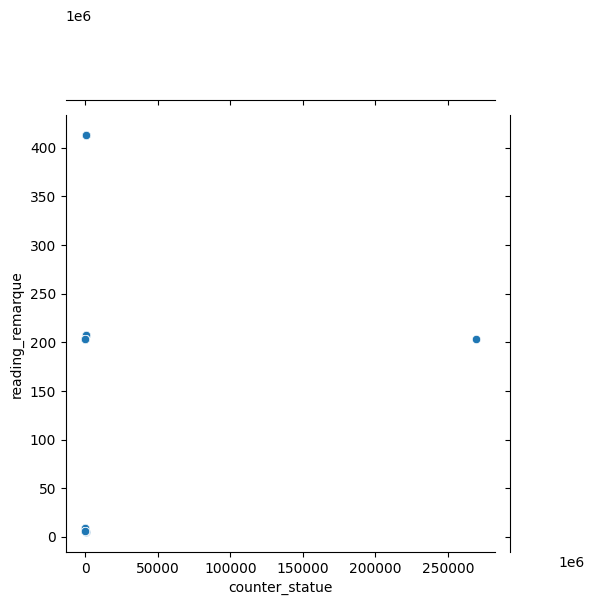

In [68]:
sns.jointplot(x="counter_statue", y="reading_remarque", data=invoice_client_train)

In [69]:
train = invoice_client_train.copy()
# counter_statue == 269375 -> can be droped, since there is just one observation and also the train_Client_53725 belong to only that observation 
train = train.query("counter_statue != 269375")
# counter_statue == 420 and reading_remarque == 5 and counter_code == 1 -> they are just one time in the same observation, so we can drop them as well
train = train.query("counter_statue != 420")
# replace string of int to int
train['counter_statue'] = train['counter_statue'].replace('0', 0)
train['counter_statue'] = train['counter_statue'].replace('1', 1)
train['counter_statue'] = train['counter_statue'].replace('4', 4)
train['counter_statue'] = train['counter_statue'].replace('5', 5)
# counter_statue == 769 and reading_remarque == 207 ???
train = train.query("counter_statue != 769")
# counter_statue == 618 and reading_remarque == 413 ???
train = train.query("counter_statue != 618")
# counter_statue == 46 and reading_remarque == 203 ???
train = train.query("counter_statue != 46")

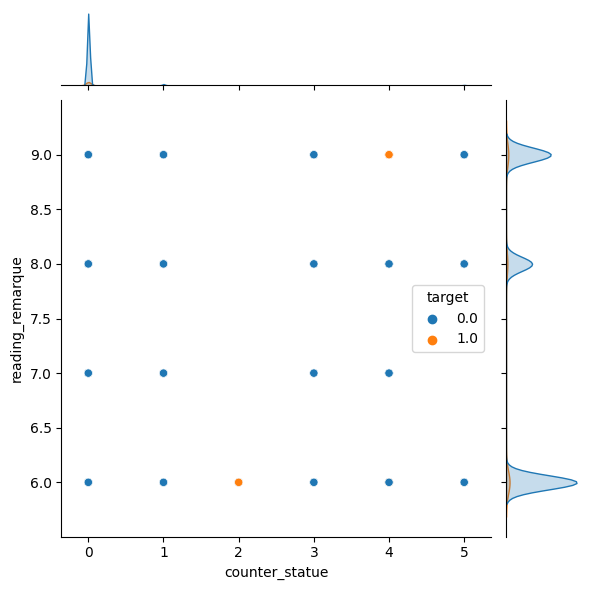

In [70]:
sns.jointplot(x="counter_statue", y="reading_remarque", hue='target', data=train)

(array([3.45295e+05, 0.00000e+00, 5.40200e+03, 0.00000e+00, 2.00000e+00,
        0.00000e+00, 1.90000e+01, 0.00000e+00, 2.35000e+02, 2.15900e+03]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ]),
 <BarContainer object of 10 artists>)

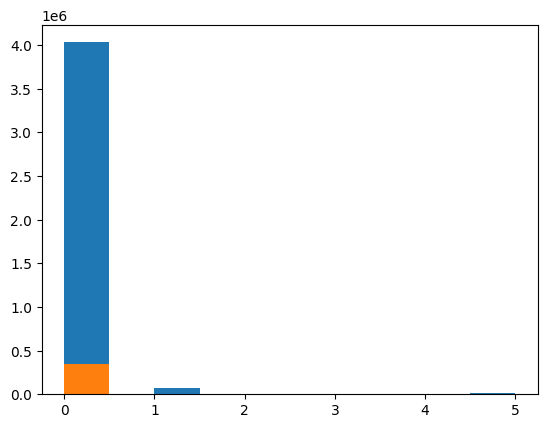

In [71]:
plt.hist(train.query('target == 0.0')['counter_statue'])
plt.hist(train.query('target == 1.0')['counter_statue'])

In [72]:
df_target_1 = train.query("target == 1.0").sort_values("invoice_date", ascending=False)
df_target_0 = train.query("target == 0.0").sort_values("invoice_date", ascending=False)

Text(0.5, 1.0, 'Counter Statue Distribution')

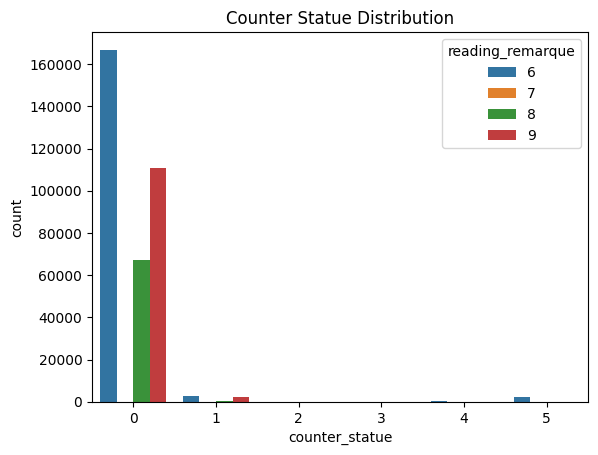

In [73]:
sns.countplot(x="counter_statue", data=df_target_1, hue="reading_remarque")
plt.title("Counter Statue Distribution")

In [74]:
df_target_1.query("reading_remarque == 7")

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
1124767,train_Client_13058,2006-09-15,40,2114874,0,5,7,1,910,0,...,9274,12,GAZ,62,11,303,22/03/1979,1.0,910,910


Text(0.5, 1.0, 'Counter Statue Distribution')

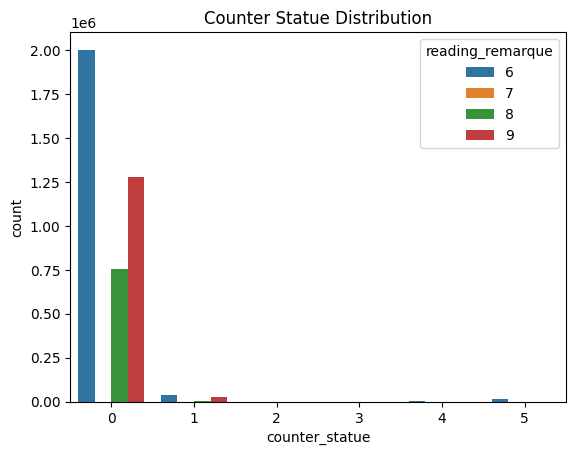

In [75]:
sns.countplot(x="counter_statue", data=df_target_0, hue="reading_remarque")
plt.title("Counter Statue Distribution")

In [76]:
df_target_0.query("reading_remarque == 7 and counter_statue == 5")

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels


In [77]:
#sns.lmplot( data = df_target_1,
#            x = 'counter_statue',
#            y = 'reading_remarque',
#            col = 'counter_code',
#            row = 'counter_coefficient',
#            hue='target'
#          )

In [78]:
#correlation = df_target_1.corr()
#mask = np.zeros_like(correlation)
#mask[np.triu_indices_from(mask)] = True 
#sns.heatmap(correlation,
#                mask = mask,
#                vmin=-1,
#                vmax=1,
#                annot = True,
#                linewidths=.5,
#                cmap = 'coolwarm',
#                square=True)

In [79]:
df_count_months = train.copy()
df_count_months.drop(columns=["invoice_date", "creation_date", "disrict", "region", "counter_type"], axis=1, inplace=True)

In [80]:
df_count_months

,client_id,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,client_catg,target,new-old_index,add_consommation_levels
0,train_Client_0,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,11,0.0,82,82
1,train_Client_0,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,11,0.0,1384,1384
2,train_Client_0,11,1335667,0,203,8,1,123,0,0,0,14624,14747,4,11,0.0,123,123
3,train_Client_0,11,1335667,0,207,8,1,102,0,0,0,14747,14849,4,11,0.0,102,102
4,train_Client_0,11,1335667,0,207,9,1,572,0,0,0,15066,15638,12,11,0.0,572,572
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4476744,train_Client_99998,10,1253571,0,202,9,1,400,135,0,0,3197,3732,8,11,0.0,535,535
4476745,train_Client_99998,10,1253571,0,202,6,1,200,6,0,0,3732,3938,4,11,0.0,206,206
4476746,train_Client_99999,11,560948,0,203,6,1,259,0,0,0,13884,14143,4,11,0.0,259,259
4476747,train_Client_99999,11,560948,0,203,6,1,603,0,0,0,13281,13884,4,11,0.0,603,603


In [81]:
train_month = train.query("months_number > 24")

In [82]:
train_month.query("consommation_level_1 == 1")

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
23280,train_Client_100641,2005-02-16,11,752718,0,207,6,1,1,5845,...,0,5314,ELEC,60,11,101,18/12/2002,0.0,0,5846
23281,train_Client_100641,2005-06-14,11,752718,0,207,6,1,1,520,...,5314,5787,ELEC,60,11,101,18/12/2002,0.0,5314,521
134406,train_Client_103631,2015-01-10,11,233057,0,207,9,1,1,0,...,1,44,ELEC,62,11,303,24/03/2011,0.0,1,1
220273,train_Client_105946,2012-01-24,11,1249613,0,203,6,1,1,0,...,1,34,ELEC,60,11,101,24/04/2009,0.0,1,1
252869,train_Client_106817,2013-09-24,11,410,1,207,8,1,1,174,...,5479,5638,ELEC,60,11,101,29/06/2011,0.0,5479,175
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3764599,train_Client_80720,2017-03-11,11,752718,0,207,9,1,1,800,...,11271,12648,ELEC,60,11,101,12/08/2016,0.0,11271,1515
3764600,train_Client_80720,2017-03-03,11,752718,0,207,9,1,1,800,...,6323,8359,ELEC,60,11,101,12/08/2016,0.0,6084,2001
3764601,train_Client_80720,2017-04-07,11,752718,0,207,9,1,1,800,...,8359,11271,ELEC,60,11,101,12/08/2016,0.0,7156,2001
3850160,train_Client_83014,2016-01-21,11,23812,0,207,8,1,1,0,...,178,32,ELEC,62,11,307,13/09/2011,0.0,1,1


In [83]:
df_count_months_size =train.query("months_number > 24").sort_values('client_id', ascending=False).groupby("client_id").size().reset_index(name="count")
df_count_months_size

,client_id,count
0,train_Client_10030,1
1,train_Client_100307,1
2,train_Client_100520,1
3,train_Client_100551,7
4,train_Client_100600,1
...,...,...
1801,train_Client_99465,68
1802,train_Client_99506,1
1803,train_Client_99772,1
1804,train_Client_99963,1


In [84]:
df_count_months_agg = df_count_months.query("months_number > 24").sort_values('client_id', ascending=False).groupby("client_id").agg(
        tarif_type_mean=('tarif_type', 'mean'),
        counter_number_mean=('counter_number', 'mean'),
        counter_statue_mean=('counter_statue', 'mean'),
        counter_code_mean=('counter_code', 'mean'),
        reading_remarque_mean=('reading_remarque', 'mean'),
        counter_coefficient_mean=('counter_coefficient', 'mean'),
        consommation_level_1_mean=('consommation_level_1', 'mean'),
        consommation_level_2_mean=('consommation_level_2', 'mean'),
        consommation_level_3_mean=('consommation_level_3', 'mean'),
        consommation_level_4_mean=('consommation_level_4', 'mean'),
        old_index_mean=('old_index', 'mean'),
        new_index_mean=('new_index', 'mean'),
        months_number_mean=('months_number', 'mean'),
        client_catg_mean=('client_catg', 'mean'),
        target_mean=('target', 'mean')).reset_index()


In [85]:
df_count_months_agg

,client_id,tarif_type_mean,counter_number_mean,counter_statue_mean,counter_code_mean,reading_remarque_mean,counter_coefficient_mean,consommation_level_1_mean,consommation_level_2_mean,consommation_level_3_mean,consommation_level_4_mean,old_index_mean,new_index_mean,months_number_mean,client_catg_mean,target_mean
0,train_Client_10030,11.0,2.541100e+04,0.000000,413.0,8.000000,1.0,6040.000000,0.000000,0.000000,0.000000,17835.000000,23875.000000,42.000000,11.0,1.0
1,train_Client_100307,10.0,2.332980e+05,0.000000,202.0,8.000000,1.0,0.000000,0.000000,0.000000,0.000000,41916.000000,41916.000000,32.000000,11.0,0.0
2,train_Client_100520,10.0,8.610800e+04,0.000000,202.0,8.000000,1.0,482.000000,0.000000,0.000000,0.000000,17641.000000,18123.000000,28.000000,11.0,0.0
3,train_Client_100551,11.0,1.020371e+06,0.714286,467.0,7.285714,1.0,4.285714,718.428571,4732.000000,0.000000,2977.428571,11222.000000,11882.571429,11.0,0.0
4,train_Client_100600,10.0,8.331541e+06,0.000000,202.0,8.000000,1.0,1688.000000,0.000000,0.000000,0.000000,6730.000000,8418.000000,40.000000,11.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1801,train_Client_99465,11.0,9.907285e+07,0.000000,506.0,7.279412,1.0,5.000000,470.588235,5167.279412,41.176471,292.720588,361000.426471,364987.161765,51.0,0.0
1802,train_Client_99506,40.0,6.873055e+06,0.000000,5.0,8.000000,1.0,3116.000000,0.000000,0.000000,0.000000,4831.000000,7947.000000,32.000000,11.0,0.0
1803,train_Client_99772,11.0,9.258960e+05,0.000000,203.0,8.000000,1.0,3414.000000,0.000000,0.000000,0.000000,8693.000000,12107.000000,28.000000,11.0,0.0
1804,train_Client_99963,11.0,4.121500e+04,0.000000,413.0,8.000000,1.0,5600.000000,2800.000000,5600.000000,512.000000,51413.000000,65925.000000,28.000000,11.0,0.0


In [86]:
df_count_months_size = df_count_months_size.merge(df_count_months_agg, on="client_id", how="left")
df_count_months_size.query("count == 1").sort_values("count", ascending=False)

,client_id,count,tarif_type_mean,counter_number_mean,counter_statue_mean,counter_code_mean,reading_remarque_mean,counter_coefficient_mean,consommation_level_1_mean,consommation_level_2_mean,consommation_level_3_mean,consommation_level_4_mean,old_index_mean,new_index_mean,months_number_mean,client_catg_mean,target_mean
0,train_Client_10030,1,11.0,25411.0,0.0,413.0,8.0,1.0,6040.0,0.0,0.0,0.0,17835.0,23875.0,42.0,11.0,1.0
1223,train_Client_60620,1,11.0,111544.0,0.0,207.0,8.0,1.0,7200.0,3037.0,0.0,0.0,28464.0,38701.0,36.0,11.0,0.0
1221,train_Client_60596,1,11.0,417829.0,0.0,203.0,9.0,1.0,3939.0,0.0,0.0,0.0,40138.0,44077.0,28.0,11.0,0.0
1219,train_Client_60516,1,40.0,77898.0,0.0,5.0,6.0,1.0,0.0,0.0,0.0,0.0,49.0,49.0,36.0,11.0,0.0
1217,train_Client_60320,1,10.0,49254.0,0.0,202.0,8.0,1.0,0.0,0.0,0.0,0.0,17113.0,17113.0,36.0,11.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
616,train_Client_22610,1,40.0,2119511.0,0.0,5.0,9.0,1.0,508.0,0.0,0.0,0.0,7961.0,8469.0,28.0,11.0,0.0
615,train_Client_2241,1,11.0,1642653.0,0.0,207.0,6.0,1.0,0.0,0.0,0.0,0.0,2488.0,2488.0,29.0,11.0,0.0
613,train_Client_22330,1,11.0,118089.0,0.0,207.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,44.0,11.0,0.0
612,train_Client_22313,1,11.0,548987.0,0.0,203.0,8.0,1.0,737.0,0.0,0.0,0.0,19353.0,20090.0,28.0,11.0,0.0


In [87]:
clients = df_count_months_size['client_id']

In [88]:
clients

0        train_Client_10030
1       train_Client_100307
2       train_Client_100520
3       train_Client_100551
4       train_Client_100600
               ...         
1801     train_Client_99465
1802     train_Client_99506
1803     train_Client_99772
1804     train_Client_99963
1805     train_Client_99992
Name: client_id, Length: 1806, dtype: object

In [89]:
train_filtered = train[invoice_client_train['client_id'].isin(clients)]

C:\Users\blabl\AppData\Local\Temp\ipykernel_26832\531047822.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  train_filtered = train[invoice_client_train['client_id'].isin(clients)]


In [90]:
train_filtered

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
10788,train_Client_10030,2016-12-26,11,25411,0,413,9,1,1600,660,...,27180,8,ELEC,62,11,310,22/09/1998,1.0,2260,2260
10789,train_Client_10030,2017-08-22,11,25411,0,413,9,1,800,128,...,29140,4,ELEC,62,11,310,22/09/1998,1.0,928,928
10790,train_Client_10030,2014-04-28,11,25411,0,413,8,1,107,0,...,23982,4,ELEC,62,11,310,22/09/1998,1.0,107,107
10791,train_Client_10030,2016-04-22,11,25411,0,413,9,1,159,0,...,24920,16,ELEC,62,11,310,22/09/1998,1.0,159,159
10792,train_Client_10030,2014-12-26,11,25411,0,413,8,1,99,0,...,24761,4,ELEC,62,11,310,22/09/1998,1.0,99,99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4476552,train_Client_99992,2019-02-20,11,48616,0,207,8,1,454,0,...,23793,4,ELEC,60,11,101,13/03/2009,0.0,454,454
4476553,train_Client_99992,2019-06-24,11,48616,0,207,8,1,490,0,...,24283,4,ELEC,60,11,101,13/03/2009,0.0,490,490
4476554,train_Client_99992,2016-10-21,11,48616,0,207,8,1,4128,0,...,19308,26,ELEC,60,11,101,13/03/2009,0.0,4128,4128
4476555,train_Client_99992,2010-06-21,11,48616,0,207,6,1,560,0,...,10371,16,ELEC,60,11,101,13/03/2009,0.0,560,560


In [91]:
##1. Grundlegende Verteilung von months_number
#
#fig, axes = plt.subplots(4, 2, figsize=(26, 10))
#
## 1. Histogramm
#sns.histplot(data=df_count_months, x='months_number', kde=True, ax=axes[0, 0])
#axes[0, 0].set_title('Verteilung months_number')
#axes[0, 0].axvline(df_count_months['months_number'].median(), color='red', linestyle='--', label='Median')
#axes[0, 0].legend()
#
## 2. Boxplot
#sns.boxplot(data=df_count_months, x='months_number', ax=axes[0, 1])
#axes[0, 1].set_title('Boxplot months_number (Ausreißer erkennen)')
#
## 3. Violinplot nach client_catg
#sns.violinplot(data=df_count_months, x='client_catg', y='months_number', ax=axes[1, 0])
#axes[1, 0].set_title('months_number nach Kundenkategorie')
#plt.xticks(rotation=45)
#
## 4. Scatter mit consumption
#sns.scatterplot(data=df_count_months, x='months_number', y='consommation_level_1', alpha=0.3, ax=axes[1, 1])
#axes[1, 1].set_title('months_number vs. Verbrauch Level 1')
#
## 4. Scatter mit consumption
#sns.scatterplot(data=df_count_months, x='months_number', y='consommation_level_2', alpha=0.3, ax=axes[2, 0])
#axes[2, 0].set_title('months_number vs. Verbrauch Level 2')
#
## 4. Scatter mit consumption
#sns.scatterplot(data=df_count_months, x='months_number', y='consommation_level_3', alpha=0.3, ax=axes[2, 1])
#axes[2, 1].set_title('months_number vs. Verbrauch Level 3')
#
## 4. Scatter mit consumption
##sns.scatterplot(data=df_count_months, x='months_number', y='consommation_level_4', alpha=0.3, ax=axes[3, 0])
#axes[3, 0].set_title('months_number vs. Verbrauch Level 4')
#
##plt.tight_layout()
#plt.show()

In [108]:
t_1 = train.query("consommation_level_1 == 1 and target == 1").sort_values("invoice_date", ascending=False) 
t_1[['client_id', 'invoice_date', 'months_number', 'consommation_level_1', 'consommation_level_2', 'consommation_level_3', 'consommation_level_4', 'old_index', 'new_index', 'tarif_type', 'counter_statue', 'reading_remarque']]


,client_id,invoice_date,months_number,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,tarif_type,counter_statue,reading_remarque
3138231,train_Client_63643,2019-12-04,4,1,0,0,0,1307,1308,40,0,8
111127,train_Client_10301,2019-11-09,4,1,0,0,0,3420,3421,40,0,8
1946426,train_Client_31119,2019-11-06,4,1,0,0,0,3388,3389,40,0,8
4185827,train_Client_92080,2019-11-04,4,1,0,0,0,2586,2587,11,0,9
255002,train_Client_106879,2019-11-02,2,1,0,0,0,4971,4972,40,0,8
...,...,...,...,...,...,...,...,...,...,...,...,...
1992267,train_Client_32319,2005-08-09,2,1,0,0,0,17601,17602,11,0,8
1814426,train_Client_27505,2005-07-13,4,1,0,0,0,10100,10101,11,0,8
3222043,train_Client_6594,2005-06-12,4,1,0,0,0,12265,12266,11,0,8
878305,train_Client_123836,2005-06-07,4,1,0,0,0,1073,1074,10,0,6


In [102]:
t_0 = train.query("consommation_level_1 == 1 and target == 0 and months_number > 20").sort_values("invoice_date", ascending=False) 
t_0[['client_id', 'invoice_date', 'months_number', 'consommation_level_1', 'consommation_level_2', 'consommation_level_3', 'consommation_level_4', 'old_index', 'new_index', 'tarif_type', 'counter_statue', 'reading_remarque']]

,client_id,invoice_date,months_number,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,tarif_type,counter_statue,reading_remarque
3764597,train_Client_80720,2018-05-03,13410,1,800,38,0,0,12648,11,0,9
4210272,train_Client_92753,2018-02-15,24,1,0,0,0,3371,3372,11,0,8
1705679,train_Client_24512,2017-08-09,32,1,0,0,0,14,15,40,0,9
4274706,train_Client_94470,2017-06-15,22,1,0,0,0,5,6,40,0,8
521359,train_Client_114050,2017-04-19,24,1,0,0,0,6233,6234,11,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...
3560346,train_Client_75146,2006-02-11,134031,1,300,1922,0,0,132011,11,0,6
3560340,train_Client_75146,2006-02-08,122846,1,300,4894,0,0,118124,11,0,6
3560335,train_Client_75146,2006-02-06,113424,1,300,2582,0,0,110804,11,0,6
23281,train_Client_100641,2005-06-14,5787,1,520,0,0,0,5314,11,0,6


In [111]:
train.query("client_id == 'train_Client_75146' and months_number > 12").sort_values("invoice_date", ascending=False)[['invoice_date', 'counter_coefficient', 'consommation_level_1', 'consommation_level_2', 'consommation_level_3', 'consommation_level_4', 'old_index', 'new_index', 'months_number', 'tarif_type', 'counter_statue', 'reading_remarque']]

,invoice_date,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,tarif_type,counter_statue,reading_remarque
3560259,2009-05-05,1,1,300,3711,0,0,212741,216388,11,0,6
3560289,2009-05-01,1,1,300,1361,0,0,202771,204281,11,0,6
3560269,2009-04-08,1,1,300,5673,0,0,223681,229111,11,0,6
3560266,2009-03-03,1,1,300,2676,0,0,206478,209184,11,0,6
3560267,2009-03-02,1,1,300,2116,0,0,204281,206478,11,0,6
3560273,2009-02-07,1,1,300,4019,0,0,219754,223681,11,0,6
3560283,2009-02-06,1,1,300,3402,0,0,216388,219754,11,0,6
3560278,2009-02-04,1,1,300,3612,0,0,209184,212741,11,0,6
3560291,2008-06-10,1,1,300,2677,0,0,196255,198962,11,0,6
3560333,2008-05-05,1,1,300,1697,0,0,182087,183903,11,0,6


In [97]:
train.query("client_id == 'train_Client_75146' and months_number <= 12").sort_values("invoice_date", ascending=False)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
3560270,train_Client_75146,2015-02-03,11,81752,0,420,9,1,1000,500,...,429351,5,ELEC,69,11,107,12/07/2002,0.0,3353,3353
3560316,train_Client_75146,2014-05-05,11,81752,0,420,9,1,200,100,...,423069,1,ELEC,69,11,107,12/07/2002,0.0,1575,1575
3560288,train_Client_75146,2014-04-03,11,81752,0,420,9,1,200,100,...,420301,1,ELEC,69,11,107,12/07/2002,0.0,980,980
3560329,train_Client_75146,2014-03-06,11,81752,0,420,9,1,76,0,...,423145,1,ELEC,69,11,107,12/07/2002,0.0,76,76
3560313,train_Client_75146,2014-03-01,11,81752,0,420,9,1,400,200,...,418201,2,ELEC,69,11,107,12/07/2002,0.0,4309,4309
3560285,train_Client_75146,2014-02-10,11,81752,0,420,9,1,200,100,...,425998,1,ELEC,69,11,107,12/07/2002,0.0,889,889
3560350,train_Client_75146,2014-02-09,11,81752,0,420,9,1,200,100,...,425109,1,ELEC,69,11,107,12/07/2002,0.0,640,640
3560332,train_Client_75146,2014-02-04,11,81752,0,420,9,1,200,100,...,421494,1,ELEC,69,11,107,12/07/2002,0.0,1193,1193
3560318,train_Client_75146,2013-07-11,11,81752,0,420,9,1,300,2616,...,413892,1,ELEC,69,11,107,12/07/2002,0.0,2916,2916
3560275,train_Client_75146,2013-04-06,11,81752,0,420,9,1,300,2880,...,399512,1,ELEC,69,11,107,12/07/2002,0.0,3180,3180


In [113]:
train.query("months_number < 100").sort_values("months_number", ascending=False)[['invoice_date', 'counter_coefficient', 'consommation_level_1', 'consommation_level_2', 'consommation_level_3', 'consommation_level_4', 'old_index', 'new_index', 'months_number', 'tarif_type', 'counter_statue', 'reading_remarque']]

,invoice_date,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,tarif_type,counter_statue,reading_remarque
1153337,2017-07-12,1,573,0,0,0,7229,7802,88,11,0,8
4430918,2017-01-03,1,0,0,0,0,22712,22712,88,11,0,6
3652048,2017-07-07,1,0,0,0,0,26300,26300,84,11,0,6
193597,2015-05-08,1,1939,0,0,0,3152,5091,82,11,0,9
3236397,2017-12-04,1,545,0,0,0,12853,13398,80,10,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...
3169978,2008-03-01,1,2004,0,0,0,25793,27797,1,40,0,9
3169977,2008-03-01,1,300,2526,0,0,53133,55959,1,11,0,6
3169976,2007-04-12,1,1196,0,0,0,24597,25793,1,40,0,6
1121364,2011-02-08,1,300,898,0,0,33675,34873,1,11,0,6


In [115]:
invoice_client_train.query("months_number > 88").groupby("target").size().reset_index(name="count")

,target,count
0,0.0,1170
1,1.0,242


In [117]:
invoice_client_train.query("months_number > 88 and target == 1")

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target,new-old_index,add_consommation_levels
566701,train_Client_115313,2015-01-27,40,2491699,0,10,6,1,3,0,...,708,708,GAZ,62,51,307,18/04/2013,1.0,708,3
566703,train_Client_115313,2016-09-21,40,2491699,0,10,6,1,3,0,...,708,708,GAZ,62,51,307,18/04/2013,1.0,708,3
566704,train_Client_115313,2016-01-26,40,2491699,0,10,6,1,3,0,...,708,708,GAZ,62,51,307,18/04/2013,1.0,708,3
566705,train_Client_115313,2015-09-15,40,2491699,0,10,6,1,3,0,...,708,708,GAZ,62,51,307,18/04/2013,1.0,708,3
566718,train_Client_115313,2014-09-22,40,2491699,0,10,6,1,3,0,...,708,708,GAZ,62,51,307,18/04/2013,1.0,708,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2687637,train_Client_51372,2018-02-02,45,5511530,0,40,6,1,3,0,...,6378,6378,GAZ,63,51,312,28/01/2016,1.0,6378,3
2687638,train_Client_51372,2016-02-08,45,5511530,0,40,9,1,3,119,...,6154,6246,GAZ,63,51,312,28/01/2016,1.0,6154,122
2687643,train_Client_51372,2017-04-07,45,5511530,0,40,6,1,3,0,...,6378,6378,GAZ,63,51,312,28/01/2016,1.0,6378,3
2687650,train_Client_51372,2017-05-12,45,5511530,0,40,6,1,3,0,...,6378,6378,GAZ,63,51,312,28/01/2016,1.0,6378,3
